# News Sentiment Pipeline — WTI Crude Oil Direction Classification

This notebook builds a complete news sentiment feature pipeline for WTI crude oil price direction prediction.

**Pipeline stages:**
1. **Data Collection** — Fetch energy/oil news headlines from Yahoo Finance via `yfinance`
2. **FinBERT Scoring** — Classify each headline as positive/negative/neutral using FinBERT
3. **Daily Aggregation** — Aggregate article-level scores into daily sentiment features
4. **Visualization** — Plot sentiment over time with rolling moving averages
5. **Integration Design** — Demonstrate how sentiment features merge into the WTI classification feature matrix

**Note on data coverage:** `yfinance` returns the ~10 most recent articles per ticker. With 21 energy-related tickers this yields ~170 unique headlines over roughly the past 10 months. Full integration into the classification models (Elastic Net, XGBoost, LSTM, VAR) would require a longer historical sentiment series — the merge and feature engineering logic in Section 5 is directly applicable once a longer history is available.

## 0. Setup

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from pathlib import Path
from transformers import pipeline as hf_pipeline
import yfinance as yf

from data_utils import load_price, PRICE_FILE

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

RAW_CSV       = DATA_DIR / "gdelt_raw_headlines.csv"
SCORED_CSV    = DATA_DIR / "gdelt_scored.csv"
SENTIMENT_CSV = DATA_DIR / "gdelt_sentiment_daily.csv"

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

GPU available: True
Device: NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Data Collection — Yahoo Finance News

We query 21 energy-related tickers across crude futures, major oil companies, oilfield services, and oil ETFs. Headlines are deduplicated by title to avoid scoring the same article multiple times.

**Tickers used:**
- Crude futures: `CL=F` (WTI), `BZ=F` (Brent)
- US majors: `XOM`, `CVX`, `COP`, `OXY`, `MPC`, `VLO`, `PSX`
- International majors: `BP`, `SHEL`, `TTE`
- Oilfield services: `HAL`, `SLB`, `BKR`, `NOV`
- ETFs: `USO`, `UCO`, `XLE`, `DBO`
- Natural gas: `NG=F`

In [16]:
TICKERS = [
    "CL=F", "BZ=F",
    "XOM", "CVX", "COP", "OXY", "MPC", "VLO", "PSX",
    "BP", "SHEL", "TTE",
    "HAL", "SLB", "BKR", "NOV",
    "USO", "UCO", "XLE", "DBO",
    "NG=F",
]

def fetch_headlines() -> pd.DataFrame:
    """Fetch recent oil/energy headlines from Yahoo Finance. Caches to disk."""
    if RAW_CSV.exists() and RAW_CSV.stat().st_size > 100:
        print(f"[SKIP] Loading cached headlines from {RAW_CSV.name}")
        return pd.read_csv(RAW_CSV, parse_dates=["date"])

    records, seen = [], set()
    for ticker in TICKERS:
        try:
            news = yf.Ticker(ticker).news
            count = 0
            for item in news:
                content = item.get("content", {})
                title   = content.get("title", "").strip()
                pub     = content.get("pubDate", "")
                if not title or not pub or title in seen:
                    continue
                seen.add(title)
                date = pd.to_datetime(pub).tz_convert(None).normalize()
                records.append({"date": date, "title": title})
                count += 1
            print(f"  {ticker}: {count} articles")
        except Exception as e:
            print(f"  {ticker}: failed ({e})")

    df = (pd.DataFrame(records)
            .drop_duplicates("title")
            .sort_values("date")
            .reset_index(drop=True))
    df.to_csv(RAW_CSV, index=False)
    print(f"\nSaved {len(df)} headlines to {RAW_CSV.name}")
    return df

raw_df = fetch_headlines()
print(f"\nTotal headlines : {len(raw_df)}")
print(f"Date range      : {raw_df['date'].min().date()} to {raw_df['date'].max().date()}")
raw_df.head(10)

  CL=F: 10 articles
  BZ=F: 10 articles
  XOM: 10 articles
  CVX: 6 articles
  COP: 7 articles
  OXY: 9 articles
  MPC: 9 articles
  VLO: 9 articles
  PSX: 7 articles
  BP: 9 articles
  SHEL: 7 articles
  TTE: 8 articles
  HAL: 9 articles
  SLB: 8 articles
  BKR: 10 articles
  NOV: 10 articles
  USO: 7 articles
  UCO: 9 articles
  XLE: 3 articles
  DBO: 7 articles
  NG=F: 9 articles

Saved 173 headlines to gdelt_raw_headlines.csv

Total headlines : 173
Date range      : 2025-05-02 to 2026-04-01


,date,title
0,2025-05-02,OPEC+ moves up video conference to discuss Jun...
1,2025-10-07,Should You Invest in Crude Oil ETFs Now?
2,2025-10-23,Oil ETFs Gain on Russian Sanctions: Can the Ra...
3,2025-10-24,"The Zacks Analyst Blog Highlights USO, BNO, DB..."
4,2025-12-23,Oil ETFs Rally Amid Intensifying U.S.-Venezuel...
5,2026-01-05,How Safe is The 5.2% Dividend On Invesco’s Oil...
6,2026-01-18,"Big Risk, Potentially Bigger Return For These ..."
7,2026-02-19,Leveraged Oil & Energy ETFs Soar on Rising U.S...
8,2026-03-03,Warning This 2x Crude Oil ETF Could Double You...
9,2026-03-06,Why Is Nov Inc. (NOV) Up 3.9% Since Last Earni...


## 2. FinBERT Sentiment Scoring

FinBERT (`ProsusAI/finbert`) is a BERT model fine-tuned on financial text. It classifies each headline as **positive**, **negative**, or **neutral** with a confidence score.

We convert to a signed scalar:
$$\text{score} = \begin{cases} +\text{confidence} & \text{if positive} \\ -\text{confidence} & \text{if negative} \\ 0 & \text{if neutral} \end{cases}$$

Inference runs in batches of 32 on GPU.

In [17]:
def signed_score(label: str, confidence: float) -> float:
    if label == "positive":  return  confidence
    if label == "negative":  return -confidence
    return 0.0

def score_with_finbert(headlines: list) -> list:
    device = 0 if torch.cuda.is_available() else -1
    print(f"Loading FinBERT on {'GPU' if device == 0 else 'CPU'} ...")
    pipe = hf_pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        device=device,
        truncation=True,
        max_length=128,
        batch_size=32,
    )
    print(f"Scoring {len(headlines)} headlines...")
    results = []
    for i in range(0, len(headlines), 1000):
        results.extend(pipe(headlines[i:i+1000]))
    return results

if SCORED_CSV.exists():
    print(f"[SKIP] Loading cached scores from {SCORED_CSV.name}")
    scored_df = pd.read_csv(SCORED_CSV, parse_dates=["date"])
else:
    results   = score_with_finbert(raw_df["title"].tolist())
    scored_df = raw_df.copy()
    scored_df["label"]        = [r["label"]  for r in results]
    scored_df["confidence"]   = [r["score"]  for r in results]
    scored_df["signed_score"] = [signed_score(r["label"], r["score"]) for r in results]
    scored_df.to_csv(SCORED_CSV, index=False)
    print(f"Saved scored headlines to {SCORED_CSV.name}")

print(f"\nLabel distribution:\n{scored_df['label'].value_counts()}")
scored_df.head(10)

[SKIP] Loading cached scores from gdelt_scored.csv

Label distribution:
label
neutral     78
positive    55
negative    40
Name: count, dtype: int64


,date,title,label,confidence,signed_score
0,2025-05-02,OPEC+ moves up video conference to discuss Jun...,neutral,0.928468,0.000000
1,2025-10-07,Should You Invest in Crude Oil ETFs Now?,neutral,0.922860,0.000000
2,2025-10-23,Oil ETFs Gain on Russian Sanctions: Can the Ra...,neutral,0.374985,0.000000
3,2025-10-24,"The Zacks Analyst Blog Highlights USO, BNO, DB...",neutral,0.950729,0.000000
4,2025-12-23,Oil ETFs Rally Amid Intensifying U.S.-Venezuel...,positive,0.534271,0.534271
5,2026-01-05,How Safe is The 5.2% Dividend On Invesco’s Oil...,neutral,0.909169,0.000000
6,2026-01-18,"Big Risk, Potentially Bigger Return For These ...",positive,0.887529,0.887529
7,2026-02-19,Leveraged Oil & Energy ETFs Soar on Rising U.S...,positive,0.863714,0.863714
8,2026-02-23,Should You Sell or Hold NOV Stock After Weak Q...,negative,0.646290,-0.646290
9,2026-02-24,Is NOV (NOV) Pricing Fairly After Recent Share...,negative,0.464608,-0.464608


In [18]:
print("--- Top 5 MOST POSITIVE ---")
for _, r in scored_df.nlargest(5, "signed_score")[["date","title","signed_score"]].iterrows():
    print(f"  [{r['date'].date()}] {r['title'][:90]}  ({r['signed_score']:.3f})")

print("\n--- Top 5 MOST NEGATIVE ---")
for _, r in scored_df.nsmallest(5, "signed_score")[["date","title","signed_score"]].iterrows():
    print(f"  [{r['date'].date()}] {r['title'][:90]}  ({r['signed_score']:.3f})")

--- Top 5 MOST POSITIVE ---
  [2026-03-31] Barclays sees strong recovery in European energy profits — key drivers explained  (0.956)
  [2026-03-26] 4 Oilfield Services Stocks Set to Gain From Strong Industry Tailwinds  (0.945)
  [2026-03-30] Can FET Continue to Deliver Strong Cash Flow Growth Momentum?  (0.942)
  [2026-03-31] Sector Update: Energy Stocks Edge Higher Pre-Bell Tuesday  (0.939)
  [2026-03-26] Assessing NOV (NOV) Valuation After US$200 Million Brazil Expansion And Strong Backlog  (0.938)

--- Top 5 MOST NEGATIVE ---
  [2026-03-28] US rig count down nine as prices increase  (-0.972)
  [2026-03-30] U.S. Natural Gas Futures Fall As Spring Weather Curbs Demand  (-0.972)
  [2026-03-30] Sector Update: Energy Stocks Decline Late Afternoon  (-0.972)
  [2026-03-27] S&P 500 Posts Fifth Consecutive Weekly Drop, Set for Biggest Monthly Loss in More Than Thr  (-0.971)
  [2026-03-30] TSX Closer: Index Closes Lower On Jitters Over the Iran War and Oil Prices  (-0.970)


## 3. Daily Aggregation

Article-level scores are grouped by date into daily features:

| Feature | Description |
|---|---|
| `avg_sentiment` | Mean signed score across all articles that day |
| `positive_pct` | Fraction of articles classified positive |
| `negative_pct` | Fraction of articles classified negative |
| `neutral_pct` | Fraction of articles classified neutral |
| `article_count` | Number of articles that day |
| `sentiment_5d_ma` | 5-day rolling mean of `avg_sentiment` |
| `sentiment_20d_ma` | 20-day rolling mean of `avg_sentiment` |

In [19]:
def aggregate_daily(df: pd.DataFrame) -> pd.DataFrame:
    daily = df.groupby("date").agg(
        avg_sentiment = ("signed_score", "mean"),
        positive_pct  = ("label", lambda x: (x == "positive").mean()),
        negative_pct  = ("label", lambda x: (x == "negative").mean()),
        neutral_pct   = ("label", lambda x: (x == "neutral").mean()),
        article_count = ("signed_score", "count"),
    ).reset_index()
    daily["sentiment_5d_ma"]  = daily["avg_sentiment"].rolling(5,  min_periods=1).mean()
    daily["sentiment_20d_ma"] = daily["avg_sentiment"].rolling(20, min_periods=1).mean()
    return daily.set_index("date").sort_index()

daily_sentiment = aggregate_daily(scored_df)
daily_sentiment.to_csv(SENTIMENT_CSV)

print(f"Days with articles : {len(daily_sentiment)}")
print(f"Date range         : {daily_sentiment.index.min().date()} to {daily_sentiment.index.max().date()}")
print(f"Avg sentiment      : {daily_sentiment['avg_sentiment'].mean():.3f}")
print(f"Positive days      : {(daily_sentiment['avg_sentiment'] > 0).sum()}")
print(f"Negative days      : {(daily_sentiment['avg_sentiment'] < 0).sum()}")
daily_sentiment

Days with articles : 29
Date range         : 2025-05-02 to 2026-03-31
Avg sentiment      : 0.146
Positive days      : 13
Negative days      : 8


,avg_sentiment,positive_pct,negative_pct,neutral_pct,article_count,sentiment_5d_ma,sentiment_20d_ma
date,,,,,,,
2025-05-02,0.000000,0.000000,0.000000,1.000000,1,0.000000,0.000000
2025-10-07,0.000000,0.000000,0.000000,1.000000,1,0.000000,0.000000
2025-10-23,0.000000,0.000000,0.000000,1.000000,1,0.000000,0.000000
2025-10-24,0.000000,0.000000,0.000000,1.000000,1,0.000000,0.000000
2025-12-23,0.534271,1.000000,0.000000,0.000000,1,0.106854,0.106854
2026-01-05,0.000000,0.000000,0.000000,1.000000,1,0.106854,0.089045
2026-01-18,0.887529,1.000000,0.000000,0.000000,1,0.284360,0.203114
2026-02-19,0.863714,1.000000,0.000000,0.000000,1,0.457103,0.285689
2026-02-23,-0.646290,0.000000,1.000000,0.000000,1,0.327845,0.182136


## 4. Visualization

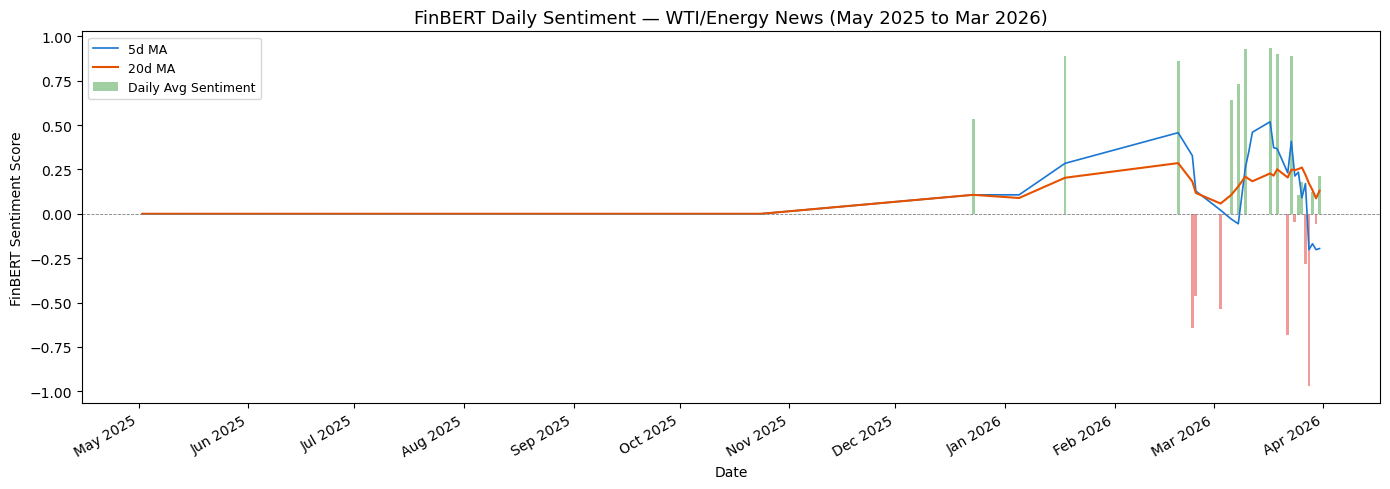

In [20]:
# Daily sentiment bars + rolling MAs
fig, ax = plt.subplots(figsize=(14, 5))

colors = ["#E53935" if v < 0 else "#43A047" for v in daily_sentiment["avg_sentiment"]]
ax.bar(daily_sentiment.index, daily_sentiment["avg_sentiment"],
       color=colors, alpha=0.5, label="Daily Avg Sentiment")
ax.plot(daily_sentiment.index, daily_sentiment["sentiment_5d_ma"],
        color="#1976D2", linewidth=1.2, label="5d MA")
ax.plot(daily_sentiment.index, daily_sentiment["sentiment_20d_ma"],
        color="#E65100", linewidth=1.5, label="20d MA")
ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_ylabel("FinBERT Sentiment Score")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
ax.legend(fontsize=9)
start = daily_sentiment.index.min().strftime("%b %Y")
end   = daily_sentiment.index.max().strftime("%b %Y")
plt.title(f"FinBERT Daily Sentiment — WTI/Energy News ({start} to {end})", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_sentiment_vs_price.png", dpi=150)
plt.show()

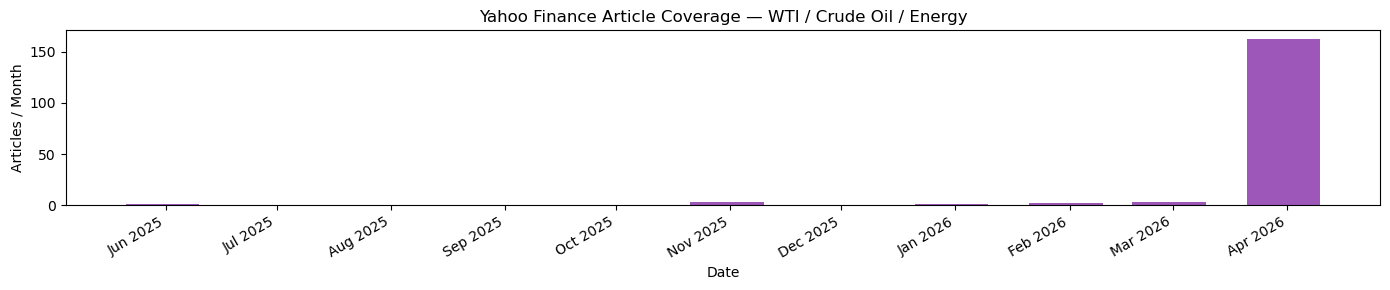

In [21]:
# Monthly article count
monthly = daily_sentiment.resample("ME")["article_count"].sum()
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(monthly.index, monthly.values, width=20, color="#7B1FA2", alpha=0.75)
ax.set_ylabel("Articles / Month")
ax.set_xlabel("Date")
ax.set_title("Yahoo Finance Article Coverage — WTI / Crude Oil / Energy", fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_article_count.png", dpi=150)
plt.show()

## 5. Integration Design — Merging Sentiment into the WTI Feature Matrix

The classification models use a feature matrix of 31 FRED-MD macro variables + 30 lagged WTI closing prices, aligned to WTI trading days. Sentiment features would be added as additional columns.

**Key alignment rules (no data leakage):**
- Sentiment on prediction day `t` may only use articles from `t-1` or earlier
- Trading days with no articles forward-fill the most recent sentiment (capped at 5 business days)
- The full sentiment series is shifted by 1 trading day before joining

In [22]:
def align_sentiment_to_price(sentiment: pd.DataFrame, price: pd.Series) -> pd.DataFrame:
    """
    Reindex sentiment to the WTI trading day calendar, forward-fill gaps
    up to 5 days, recompute rolling MAs, then lag by 1 day to prevent leakage.
    """
    aligned = sentiment.reindex(price.index).ffill(limit=5)
    aligned["sentiment_5d_ma"]  = aligned["avg_sentiment"].rolling(5,  min_periods=1).mean()
    aligned["sentiment_20d_ma"] = aligned["avg_sentiment"].rolling(20, min_periods=1).mean()
    return aligned.shift(1)   # lag 1 day — prediction on t uses sentiment from t-1

price = load_price(PRICE_FILE)

overlap_start = daily_sentiment.index.min()
overlap_end   = min(daily_sentiment.index.max(), price.index.max())
price_overlap = price[(price.index >= overlap_start) & (price.index <= overlap_end)]

print(f"Price data ends      : {price.index.max().date()}")
print(f"Sentiment range      : {daily_sentiment.index.min().date()} to {daily_sentiment.index.max().date()}")
print(f"Overlap window       : {overlap_start.date()} to {overlap_end.date()}")
print(f"Overlap trading days : {len(price_overlap)}")

Price data ends      : 2025-10-31
Sentiment range      : 2025-05-02 to 2026-03-31
Overlap window       : 2025-05-02 to 2025-10-31
Overlap trading days : 133


In [23]:
SENTIMENT_FEATURES = ["avg_sentiment", "positive_pct", "negative_pct", "sentiment_5d_ma"]

if len(price_overlap) > 0:
    aligned = align_sentiment_to_price(daily_sentiment, price_overlap)
    feature_df = pd.DataFrame({"wti_close": price_overlap})
    feature_df["direction"] = (feature_df["wti_close"].diff() > 0).astype(int)
    feature_df = feature_df.join(aligned[SENTIMENT_FEATURES])
    n_filled = feature_df["avg_sentiment"].notna().sum()
    print(f"Rows with sentiment data: {n_filled} / {len(feature_df)}")
    print()
    print(feature_df.dropna().to_string())
else:
    print("No overlap between sentiment dates and price data.")
    print("Price data ends Oct 2025; most headlines are from Nov 2025 onward.")
    print()
    print("The feature matrix structure (once price data is extended):")
    example = daily_sentiment[SENTIMENT_FEATURES].head(8).copy()
    example.insert(0, "wti_close", "[price]")   # placeholder column
    example.insert(1, "direction", "[0 or 1]")   # placeholder column
    print(example.to_string())

Rows with sentiment data: 18 / 133

            wti_close  direction  avg_sentiment  positive_pct  negative_pct  sentiment_5d_ma
Date                                                                                        
2025-05-05      57.13          0            0.0           0.0           0.0              0.0
2025-05-06      59.09          1            0.0           0.0           0.0              0.0
2025-05-07      58.07          0            0.0           0.0           0.0              0.0
2025-05-08      59.91          1            0.0           0.0           0.0              0.0
2025-05-09      61.02          1            0.0           0.0           0.0              0.0
2025-05-12      61.56          1            0.0           0.0           0.0              0.0
2025-10-08      62.55          1            0.0           0.0           0.0              0.0
2025-10-09      61.51          0            0.0           0.0           0.0              0.0
2025-10-10      58.90          0  

## 6. Sentiment Distribution and Correlation

We show the overall sentiment distribution and, where overlap with price data exists, compute the Pearson correlation between lagged sentiment and next-day direction.

FinBERT label distribution across all headlines:
  neutral   : 45.1%
  positive  : 31.8%
  negative  : 23.1%


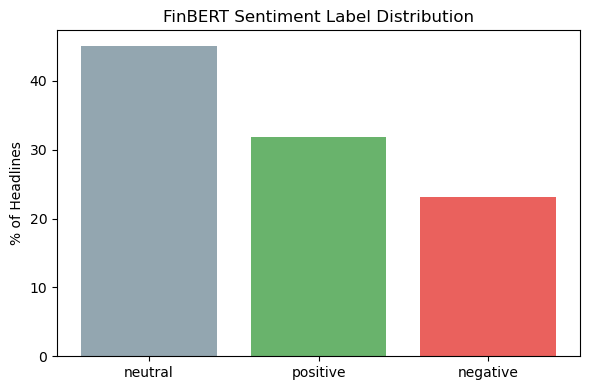

In [24]:
# Sentiment label distribution
dist = scored_df["label"].value_counts(normalize=True).mul(100).round(1)
print("FinBERT label distribution across all headlines:")
for label, pct in dist.items():
    print(f"  {label:10s}: {pct:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"positive": "#43A047", "negative": "#E53935", "neutral": "#78909C"}
ax.bar(dist.index, dist.values, color=[colors[l] for l in dist.index], alpha=0.8)
ax.set_ylabel("% of Headlines")
ax.set_title("FinBERT Sentiment Label Distribution", fontsize=12)
plt.tight_layout()
plt.show()

In [25]:
# Correlation on overlap period (if enough data)
if len(price_overlap) > 0 and 'feature_df' in dir():
    corr_df = feature_df[["direction"] + SENTIMENT_FEATURES].dropna()
    if len(corr_df) >= 3:
        print("Pearson correlation with next-day direction (1=up, 0=down):")
        print(corr_df.corr()["direction"].drop("direction").to_string())
    else:
        print(f"Only {len(corr_df)} overlapping rows — not enough for meaningful correlation.")
        print("Extend price data to Nov 2025+ to compute this.")
else:
    print("Correlation requires price/sentiment overlap. Extend price data to compute.")

Pearson correlation with next-day direction (1=up, 0=down):
avg_sentiment     NaN
positive_pct      NaN
negative_pct      NaN
sentiment_5d_ma   NaN


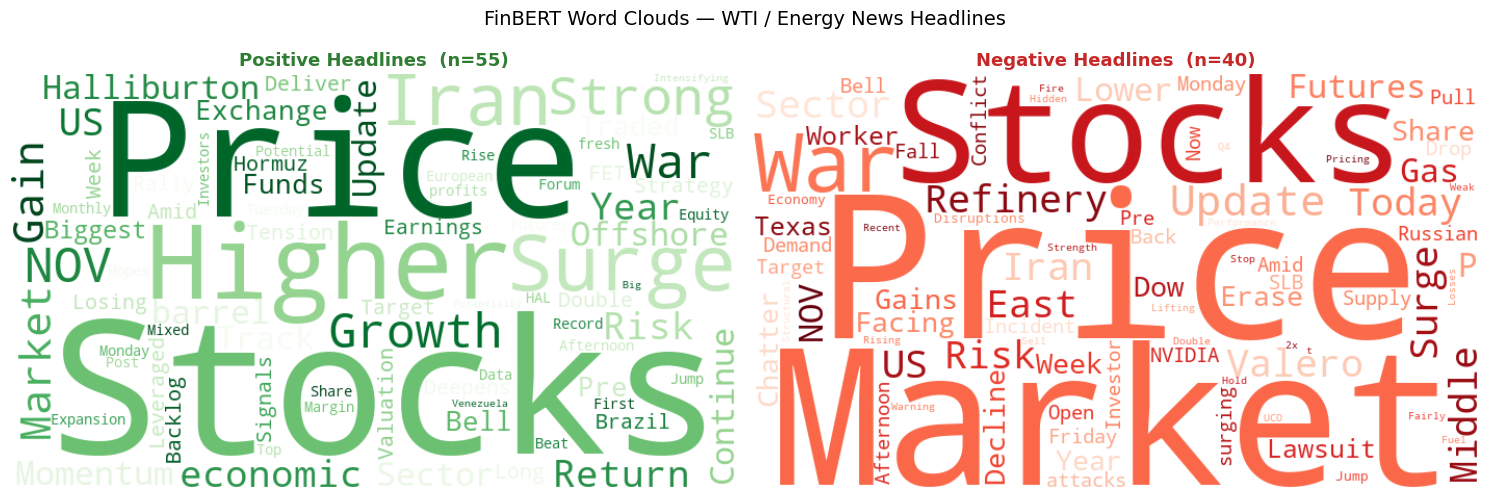

In [28]:
try:
    from wordcloud import WordCloud, STOPWORDS
    _wc_available = True
except ImportError:
    _wc_available = False
    print("wordcloud not installed — run: pip install wordcloud")

if _wc_available:
    _extra_stops = {
        "stock", "oil", "energy", "crude", "etf", "etfs", "says", "new",
        "will", "can", "set", "get", "s", "u", "one", "using", "use",
    }
    STOPS = STOPWORDS | _extra_stops

    pos_text = " ".join(scored_df.loc[scored_df["label"] == "positive", "title"])
    neg_text = " ".join(scored_df.loc[scored_df["label"] == "negative", "title"])

    wc_pos = WordCloud(
        width=700, height=400,
        background_color="white",
        colormap="Greens",
        stopwords=STOPS,
        max_words=80,
        collocations=False,
    ).generate(pos_text)

    wc_neg = WordCloud(
        width=700, height=400,
        background_color="white",
        colormap="Reds",
        stopwords=STOPS,
        max_words=80,
        collocations=False,
    ).generate(neg_text)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].imshow(wc_pos, interpolation="bilinear")
    axes[0].axis("off")
    n_pos = (scored_df["label"] == "positive").sum()
    axes[0].set_title(f"Positive Headlines  (n={n_pos})", fontsize=13, color="#2E7D32", fontweight="bold")

    axes[1].imshow(wc_neg, interpolation="bilinear")
    axes[1].axis("off")
    n_neg = (scored_df["label"] == "negative").sum()
    axes[1].set_title(f"Negative Headlines  (n={n_neg})", fontsize=13, color="#C62828", fontweight="bold")

    plt.suptitle("FinBERT Word Clouds — WTI / Energy News Headlines", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(DATA_DIR / "fig_wordclouds.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Positive vs. Negative Word Cloud

Words that appear most frequently in **positive-classified** headlines (left) vs **negative-classified** headlines (right). Size reflects frequency. This makes it easy to see which concepts FinBERT associates with bullish vs bearish energy news.

[SKIP] Loading cached ticker headlines from headlines_by_ticker.csv


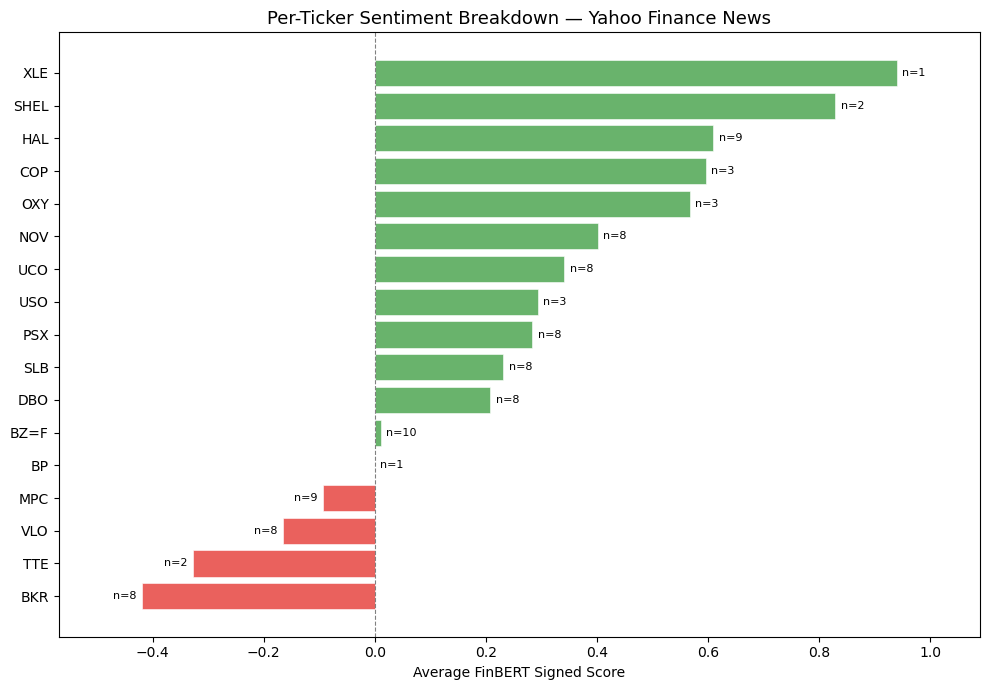

        avg_sentiment  n_articles
ticker                           
BKR         -0.419116           8
TTE         -0.326470           2
VLO         -0.164685           8
MPC         -0.093772           9
BP           0.000000           1
BZ=F         0.010575          10
DBO          0.207932           8
SLB          0.231267           8
PSX          0.283072           8
USO          0.293173           3
UCO          0.340695           8
NOV          0.401611           8
OXY          0.567163           3
COP          0.595731           3
HAL          0.608835           9
SHEL         0.828587           2
XLE          0.939479           1


In [29]:
TICKER_CSV = DATA_DIR / "headlines_by_ticker.csv"

def fetch_headlines_by_ticker() -> pd.DataFrame:
    """Fetch headlines keyed by source ticker (may have duplicate titles across tickers).

    Returns:
        DataFrame with columns [ticker, date, title].
        Cached to TICKER_CSV to avoid re-fetching.
    """
    if TICKER_CSV.exists():
        print(f"[SKIP] Loading cached ticker headlines from {TICKER_CSV.name}")
        return pd.read_csv(TICKER_CSV, parse_dates=["date"])

    records = []
    for ticker in TICKERS:
        try:
            news = yf.Ticker(ticker).news
            for item in news:
                content = item.get("content", {})
                title   = content.get("title", "").strip()
                pub     = content.get("pubDate", "")
                if not title or not pub:
                    continue
                date = pd.to_datetime(pub).tz_convert(None).normalize()
                records.append({"ticker": ticker, "date": date, "title": title})
        except Exception as e:
            print(f"  {ticker}: failed ({e})")

    df = pd.DataFrame(records).sort_values(["ticker", "date"]).reset_index(drop=True)
    df.to_csv(TICKER_CSV, index=False)
    print(f"Saved {len(df)} ticker-headline rows to {TICKER_CSV.name}")
    return df

ticker_df = fetch_headlines_by_ticker()

# Join sentiment scores from scored_df (unique titles)
title_scores = scored_df[["title", "signed_score", "label"]].drop_duplicates("title")
ticker_scored = ticker_df.merge(title_scores, on="title", how="left").dropna(subset=["signed_score"])

# Average sentiment per ticker
ticker_avg = (ticker_scored
              .groupby("ticker")
              .agg(avg_sentiment=("signed_score", "mean"),
                   n_articles=("title", "nunique"))
              .sort_values("avg_sentiment"))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ["#E53935" if v < 0 else "#43A047" for v in ticker_avg["avg_sentiment"]]
bars = ax.barh(ticker_avg.index, ticker_avg["avg_sentiment"],
               color=bar_colors, alpha=0.8, edgecolor="white", linewidth=0.5)

# Annotate with article count
for i, (idx, row) in enumerate(ticker_avg.iterrows()):
    x_pos = row["avg_sentiment"] + (0.01 if row["avg_sentiment"] >= 0 else -0.01)
    ha    = "left" if row["avg_sentiment"] >= 0 else "right"
    ax.text(x_pos, i, f"n={int(row['n_articles'])}", va="center", ha=ha, fontsize=8)

ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Average FinBERT Signed Score")
ax.set_title("Per-Ticker Sentiment Breakdown — Yahoo Finance News", fontsize=13)
ax.set_xlim(ticker_avg["avg_sentiment"].min() - 0.15,
            ticker_avg["avg_sentiment"].max() + 0.15)
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_ticker_sentiment.png", dpi=150)
plt.show()

print(ticker_avg.to_string())

## 7. Per-Ticker Sentiment Breakdown

Average FinBERT signed score per source ticker across all headlines. A ticker's bar reflects the market sentiment in news published under that symbol — useful for identifying which companies or instruments are covered most positively or negatively.

## Summary

| Stage | Status | Output |
|---|---|---|
| News fetch (Yahoo Finance, 21 tickers) | Complete | `gdelt_raw_headlines.csv` |
| FinBERT scoring on GPU | Complete | `gdelt_scored.csv` |
| Daily aggregation | Complete | `gdelt_sentiment_daily.csv` |
| Alignment & lag logic | Implemented | Demonstrated in Section 5 |
| Full model integration | Pending extended price data | Code ready to apply |

**Sentiment features to add to each classification model:**

| Feature | Rationale |
|---|---|
| `avg_sentiment` | Primary signal — signed FinBERT confidence |
| `positive_pct` | Proportion of bullish coverage |
| `negative_pct` | Proportion of bearish coverage |
| `sentiment_5d_ma` | Smoothed short-term sentiment trend |

All features are **lagged by 1 trading day** before being passed to any model to prevent data leakage.